In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load Digits Dataset (similar to MNIST, smaller version)
digits = load_digits()
X, y = digits.data, digits.target

print("✅ Dataset Loaded!")
print("Data shape  :", X.shape)
print("Image size  : 8x8 pixels")
print("Classes     :", len(np.unique(y)))

✅ Dataset Loaded!
Data shape  : (1797, 64)
Image size  : 8x8 pixels
Classes     : 10


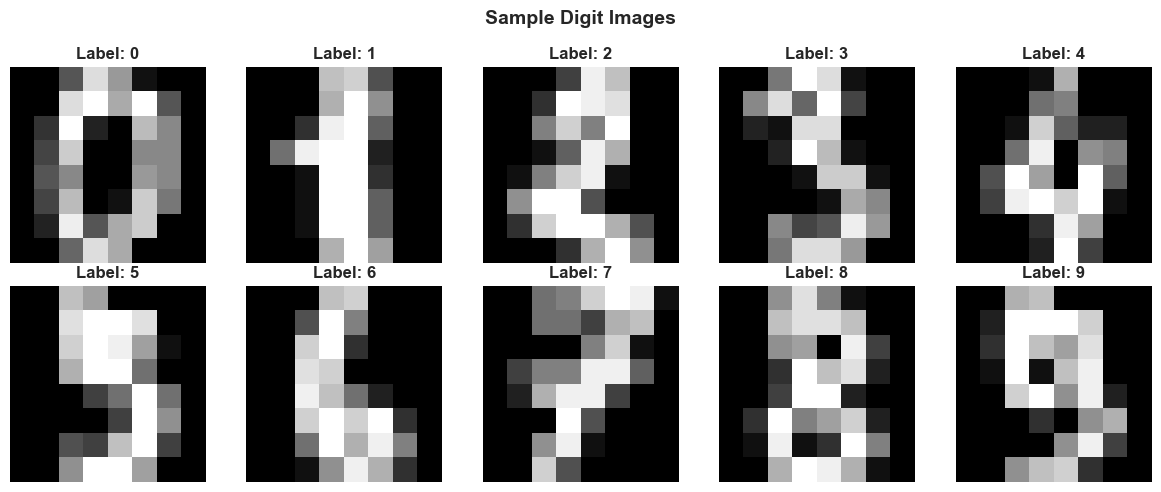

✅ Sample images displayed!


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(digits.images[i], cmap='gray')
    axes[i].set_title(f'Label: {digits.target[i]}', fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Sample Digit Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Sample images displayed!")

In [4]:
print("Before normalization - Min:", X.min(), "Max:", X.max())

# Normalize pixel values to [0,1]
X_norm = X / 16.0   # digits dataset pixel values range 0-16

print("After  normalization - Min:", X_norm.min(), "Max:", X_norm.max())
print("✅ Pixel values normalized to [0,1]!")

Before normalization - Min: 0.0 Max: 16.0
After  normalization - Min: 0.0 Max: 1.0
✅ Pixel values normalized to [0,1]!


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=42)

print("✅ Train-Test Split Done!")
print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

✅ Train-Test Split Done!
Training samples : 1437
Testing  samples : 360


In [6]:
# MLPClassifier = Multi-Layer Perceptron (ANN)
# hidden_layer_sizes = Dense layers
# activation='relu' for hidden layers
# Softmax is automatically used internally for multi-class output

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # Two Dense hidden layers
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)

print("✅ ANN Model Trained!")
print("Hidden Layers:", model.hidden_layer_sizes)
print("Number of iterations:", model.n_iter_)

✅ ANN Model Trained!
Hidden Layers: (128, 64)
Number of iterations: 166


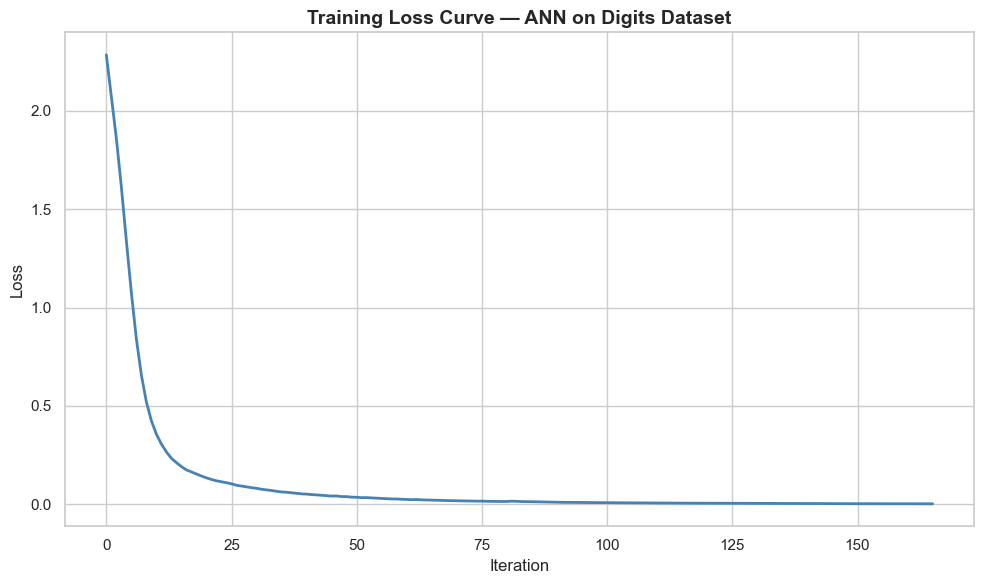

✅ Loss curve plotted!


In [7]:
plt.figure(figsize=(10, 6))
plt.plot(model.loss_curve_, color='steelblue', linewidth=2)
plt.title('Training Loss Curve — ANN on Digits Dataset',
          fontsize=14, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()
print("✅ Loss curve plotted!")

In [8]:
y_pred = model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print("=" * 45)
print("      MODEL EVALUATION RESULTS")
print("=" * 45)
print(f"✅ Test Accuracy : {test_accuracy*100:.2f}%")
print("=" * 45)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

      MODEL EVALUATION RESULTS
✅ Test Accuracy : 97.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.96      0.94      0.95        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.97       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.97      0.97       360



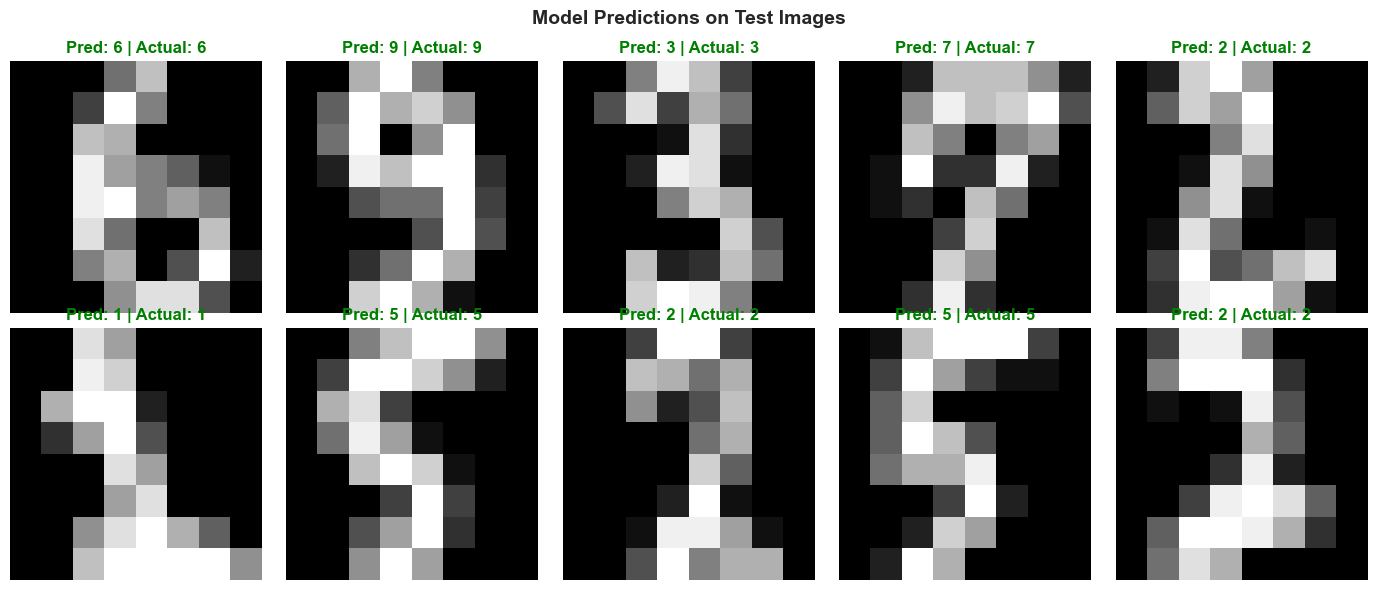

✅ Predictions Visualized! (Green=Correct, Red=Wrong)


In [9]:
sample_indices = np.arange(10)
X_test_sample = X_test[sample_indices]
y_test_sample = y_test[sample_indices]
y_pred_sample = model.predict(X_test_sample)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i in range(10):
    img = X_test_sample[i].reshape(8, 8)
    axes[i].imshow(img, cmap='gray')
    color = 'green' if y_pred_sample[i] == y_test_sample[i] else 'red'
    axes[i].set_title(f'Pred: {y_pred_sample[i]} | Actual: {y_test_sample[i]}',
                      color=color, fontweight='bold')
    axes[i].axis('off')
plt.suptitle('Model Predictions on Test Images',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Predictions Visualized! (Green=Correct, Red=Wrong)")

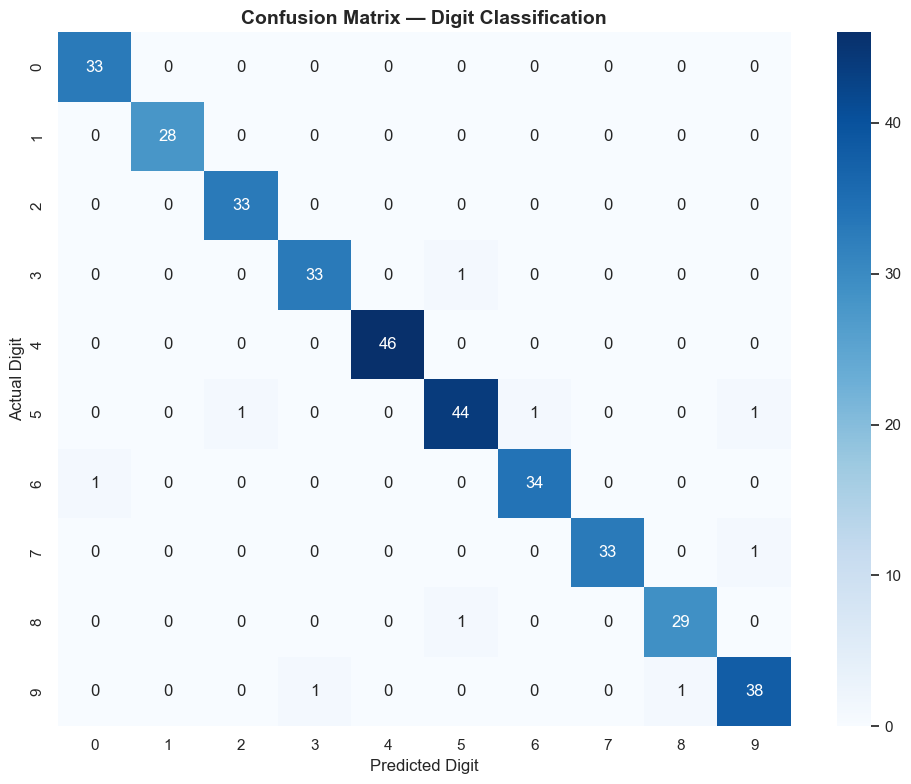

✅ Confusion Matrix plotted!


In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix — Digit Classification',
          fontsize=14, fontweight='bold')
plt.ylabel('Actual Digit')
plt.xlabel('Predicted Digit')
plt.tight_layout()
plt.show()
print("✅ Confusion Matrix plotted!")


INTERVIEW QUESTIONS — ANSWERS
══════════════════════════════════════════════════════

Q1. What is an Activation Function?
    An activation function decides whether a neuron
    should be "activated" (fire) or not.
    It adds NON-LINEARITY to the network, so the model
    can learn complex patterns (not just straight lines).

    Common Activation Functions:
    - ReLU (Rectified Linear Unit)
      f(x) = max(0, x)
      Used in hidden layers, fast and avoids vanishing
      gradient problem

    - Sigmoid
      f(x) = 1 / (1 + e^-x)
      Output between 0 and 1, used for binary classification

    - Softmax
      Converts outputs into probabilities that sum to 1
      Used in FINAL layer for multi-class classification
      (like our 10-digit output)

Q2. Why is Normalization important in Deep Learning?
    Pixel values originally range from 0 to 16 (or 0-255
    for full images).
    Normalization scales them to a smaller range [0,1].

    Benefits:
    1. Faster training — gradient descent converges quicker
    2. Prevents large numbers from dominating calculations
    3. Avoids exploding gradients during backpropagation
    4. Makes all features contribute equally
    5. Improves model accuracy and stability

    Without normalization, large pixel values can cause
    unstable weight updates and slow learning.

══════════════════════════════════════════════════════
